# **TAS (Tele Assistance System) Analytical Calibration**
NOTE: _[DASA CASE STUDY 1]_

## **Summary**

This notebook is focused on three main objectives:
1. summarizing the key aspects of the Tele Assistance System (TAS) architecture and its adaptive capabilities in the context of telehealth services for chronic patients.
2. Modelling the TAS architecture using appropriate design notations and tools to visualize its components and interactions.
3. Simulating the TAS behavior under different scenarios to evaluate its performance and adaptability with Queue Network (QN) models.

The results will be used to evaluate the Dimensional Analysis for CUSTOM Architecture (DASA) methodology, its CUSTOM tool (PyDASA) and its effectiveness in modelling and Quality Scenarios (QS) trade-off in self-adaptive-systems (SAS).

---

## **Software Architecture**
- TAS (Tele Assistance System) operates in a dynamic environment where service quality, availability, and user needs frequently change.
- The TAS is further subdivided into Controller and Target System subsystem components.
- The Controller is responsible for managing the overall system behavior, while the Target System focuses on executing specific tasks related to patient care.
- The TAS target systems follows a Service-oriented architecture (SOA) pattern.
- The TAS Controller follows a MAPE-K (Monitor-Analyze-Plan-Execute-Knowledge) feedback loop for self-adaptation.
- Adaptations focus on maintaining **reliability**, **performance**, and **compliance** with patient care standards (5 specific scenarios).
- ActivFORMS provides the runtime framework for model-based adaptation using runtime models, simulations, and verified decision-making.

---

_**NOTE: MORE DETAILS ON THE ARCHITECTURE IN THE ANALYTICAL MODELLING NOTEBOOK!.**_

---

#### **Queue Network Model**

<svg viewBox="0 0 4650 2000" width="1400" height="650">
    <!-- SVG content -->
    <image href="assets/cs1/img/04A - Queue Network.svg" alt="queue-net-diagram" />
    <div align="center"><em>Image 4. TAS Queue Network Diagram.</em></div>
</svg>

## **Code**

_**SUMMARY:**_

This code is for the analytical solution of the Case Study (TAS) Queue Network Model and is structured as follows:
1. Analytical Queue Network (QN) model.
2. Importing necessary libraries and modules.
3. Loading QN default configuration.
4. Solving the QN analytically (Jackson Network).
5. Plotting the QN with the obtained metrics.
6. Loading QN 'optimal' configuration.
7. Solving the QN optimally (Jackson Network).
8. Plotting the optimal QN with the obtained metrics.
9. Saving the results.
10. Comparing the analytical results (Default Vs. Optimal)
11. Visualizing the results.
12. Generating a summary report.

### **Necessary Imports**

In [1]:
# -*- coding: utf-8 -*-
# Native imports
import os
import re
import sys
import time
from typing import Union

# Third-party imports
import numpy as np
import pandas as pd

# import queue network + models packages
from src.model.queueing import Queue
from src.model.analytical import solve_jackson_network
from src.model.analytical import calculate_net_metrics

# import plot functions + grahics
from src.view.plots import plot_queue_network
from src.view.plots import plot_net_comparison
from src.view.plots import plot_net_difference
from src.view.plots import plot_nodes_heatmap
from src.view.plots import plot_nodes_diffmap
from src.view.plots import plot_calibration_curves

### **Function Definitions**

In [2]:
# Simple formatter for console output

def fmt(val: Union[int, float, np.number]) -> Union[str, np.ndarray]:
    """Format a number to 4 decimal places for console output.

    Args:
        val (Union[int, float, np.number, np.ndarray]): The value to format.

    Returns:
        Union[str, np.ndarray]: The formatted value as a string or an array of strings.
    """
    if isinstance(val, (int, float, np.number)):
        if np.isnan(val) or np.isinf(val):
            return str(val)
        return f"{val:.4f}"
    elif isinstance(val, np.ndarray):
        return np.array([fmt(x) for x in val])
    return val

In [3]:
# Load configuration from a CSV file
def load(path: str, fname: str) -> pd.DataFrame:
    """Load configuration from a CSV file.

    Args:
        path (str): The directory path where the CSV file is located.
        fname (str): The name of the CSV file to load.

    Returns:
        pd.DataFrame: A DataFrame containing the configuration data.
            CSV format:
                - node: <node_id>
                - mu: <mean_service_time>
                - c: <service_channels>
                - K: <buffer_capacity | max_queue_length>
                - lambda0: <initial_arrival_rate>
                - L0: <initial_queue_length>
                - pm: <matrix_routing_probabilities>
    """
    # path = os.path.dirname(__file__)
    _file_path = os.path.join(path, fname)
    print(f"Loading configuration from: {_file_path}")
    df = pd.read_csv(_file_path)
    return df

In [4]:
# save dataframes in CSV files
def save(path: str, fname: str, data: pd.DataFrame) -> None:
    """Save a DataFrame to a CSV file.

    Args:
        path (str): The directory path where the CSV file will be saved.
        fname (str): The name of the CSV file to save.
        data (pd.DataFrame): The DataFrame containing the data to save.
    """
    # path = os.path.dirname(__file__)
    _file_path = os.path.join(path, fname)
    print(f"Saving data to: {_file_path}")
    data.to_csv(_file_path, index=False)

In [5]:
def config_analytical_model(cfg_df: pd.DataFrame, verbose=False) -> tuple:
    """Configure the analytical queue model based on the provided configuration DataFrame.

    Args:
        cfg_df (pd.DataFrame): configuration DataFrame
        verbose (bool, optional): If True, print detailed information. Defaults to False.

    Returns:
        tuple: A tuple containing the configured parameters and queue objects specifically:
            - mus (list): List of service rates.
            - lambda_zs (list): List of arrival rates.
            - queues (list): List of configured Queue objects.
            - P (np.ndarray): Routing probability matrix.
    """

    # extract parameters from the configuration DataFrame
    # and casting them to proper types
    nodes = cfg_df["node"].values.astype(int).tolist()
    names = cfg_df["name"].values.tolist()
    types = cfg_df["type"].values.tolist()
    mus = cfg_df["mu"].values.tolist()
    lambda_zs = cfg_df["lambda_z"].values.tolist()
    n_servers = cfg_df["c"].values.astype(int).tolist()
    kaps = cfg_df["K"].values.astype(int).tolist()

    # Convert K=0=nan to understandable infinite capacity -> None
    for i in range(len(kaps)):
        if np.isnan(kaps[i]):
            if verbose:
                _msg = f"Node {nodes[i]}: K is 'NaN', "
                _msg += "setting capacity to None (infinite)"
                print(_msg)
            kaps[i] = None
        else:
            kaps[i] = int(kaps[i])

    # Convert string representations of arrays to actual numpy arrays
    # and create routing matrix P
    prob = []
    for pm_str in cfg_df["P_routing"].values.tolist():
        routing_val = pm_str.strip("[]").split(",")
        routing_val = [float(val) for val in routing_val]
        prob.append(routing_val)
    P_routing = np.array((prob))

    # create queue objects based on the configuration
    queues = []
    for i in range(len(mus)):
        if verbose:
            _msg = f"Creating queue: '{names[i]}' for Node: {nodes[i]}"
            print(_msg)
            _msg = f"  Type: {types[i]}, λ: {lambda_zs[i]}, "
            _msg += f"μ: {mus[i]}, s: {n_servers[i]}, K: {kaps[i]}"
            print(_msg)
        # create queue object
        q = Queue(
            model=types[i],
            _lambda=lambda_zs[i],
            mu=mus[i],
            n_servers=n_servers[i],
            kapacity=kaps[i],
        )
        # add queue to the list
        queues.append(q)

    # create analytical model tuple
    ans = (mus, lambda_zs, queues, P_routing)
    return ans

### **Working Code**

In [6]:
# path = os.path.dirname(__file__)\
PATH = os.getcwd()
print(f"Notebook path: {PATH}")

Notebook path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies


In [7]:
# Folder names
config_folder = "config"
test_folder = "tests"
calib_folder = "calibration"
docs_folder = "docs"
img_folder = "img"
data_folder = "data"
report_folder = "reports"
results_folder = "results"
cs_folder = "cs1"

In [8]:
# setting case study data folder
file_path = os.path.join(PATH,
                         test_folder,
                         calib_folder,
                         data_folder,
                         config_folder,
                         cs_folder)
print(f"Configuration file path: {file_path}")

Configuration file path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\tests\calibration\data\config\cs1


### **Queue Model**

#### **Calibrating awith the Analytical Solution**

##### **Base Configuration**

In [9]:
# Load configuration with mixed queue models
dflt_qn_cfg = load(file_path, "dflt_calib_qn_model.csv")
print("Queue Network Configuration:")
# print(dflt_qn_cfg)
dflt_qn_cfg.head()

Loading configuration from: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\tests\calibration\data\config\cs1\dflt_calib_qn_model.csv
Queue Network Configuration:


,node,name,type,mu,c,K,lambda_z,L_z,P_routing
0,1,TAS 1 (1)*,M/M/s/K,900,1,10,345,0,"[0.00,0.75,0.25,0.00,0.00,0.00,0.00,0.00,0.00,..."
1,2,TAS 2 (1)*,M/M/s/K,700,1,10,0,0,"[0.00,0.00,0.00,0.33,0.33,0.33,0.00,0.00,0.00,..."
2,3,TAS 3 (1)*,M/M/s/K,700,1,10,0,0,"[0.00,0.00,0.00,0.00,0.00,0.00,0.33,0.33,0.33,..."
3,4,MAS 1,M/M/s/K,180,1,10,0,0,"[0.00,0.00,0.00,0.12,0.00,0.00,0.00,0.00,0.00,..."
4,5,MAS 2,M/M/s/K,530,1,10,0,0,"[0.00,0.00,0.00,0.00,0.07,0.00,0.00,0.00,0.00,..."


In [10]:
print("--- Configuring default analytical model... ---")
dflt_analytical_model = config_analytical_model(dflt_qn_cfg,
                                                verbose=False)
start_lamba_zp = dflt_analytical_model[1][0]
print(f"Starting arrival rate lambda_z at Node 0: {fmt(start_lamba_zp)}")

--- Configuring default analytical model... ---
Starting arrival rate lambda_z at Node 0: 345.0000


In [11]:
# Solve the network analytically
# first node metrics
dflt_analyt_nd_metrics = solve_jackson_network(*dflt_analytical_model)

In [12]:
print(f"--- Configurating Default Calibration Dataframe ---")
# dflt_analyt_nd_metrics.info()
idx_cols = dflt_analyt_nd_metrics["node"].values.tolist()
named_cols = dflt_analyt_nd_metrics.columns.tolist()
if "node" in named_cols:
    named_cols.remove("node")

print(f"Index columns: {idx_cols}")
print(f"Named columns: {named_cols}")

# create calibration dataframe idx + named colums for each idx
calib_cols = []
for idx in idx_cols:
    for ncol in named_cols:
        tgt_col = f"{ncol}_{{{idx}}}"
        if ncol in ("lambda", "rho", "mu"):
            tgt_col = f"\\{tgt_col}"
        calib_cols.append(tgt_col)
calib_df = pd.DataFrame(columns=calib_cols)
print(f"Default Calibration DataFrame shape: {calib_df.shape}")
calib_df.head()

--- Configurating Default Calibration Dataframe ---
Index columns: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Named columns: ['lambda', 'mu', 'rho', 'L', 'Lq', 'W', 'Wq']
Default Calibration DataFrame shape: (0, 91)


,\lambda_{1},\mu_{1},\rho_{1},L_{1},Lq_{1},W_{1},Wq_{1},\lambda_{2},\mu_{2},\rho_{2},...,Lq_{12},W_{12},Wq_{12},\lambda_{13},\mu_{13},\rho_{13},L_{13},Lq_{13},W_{13},Wq_{13}


In [13]:
print("--- Starting Calibration Loop ---")
RHO_CRIT = 1.0
LAMBDA_CRIT = start_lamba_zp
while any(dflt_analyt_nd_metrics["rho"] < RHO_CRIT):
    # print(f"\tλ_zero at Node 0: {fmt(dflt_analytical_model[1][0])}")
    
    # error raise iignore and finish the loop
    try:
        dflt_analyt_nd_metrics = solve_jackson_network(*dflt_analytical_model)
        
        # adding the metrics to the calibration dataframe
        calib_row = {}
        for _, row in dflt_analyt_nd_metrics.iterrows():
            node_id = int(row["node"])
            for ncol in named_cols:
                tgt_col = f"{ncol}_{{{node_id}}}"
                if ncol in ("lambda", "rho", "mu") :
                    tgt_col = f"\\{tgt_col}"
                
                calib_row[tgt_col] = row[ncol]
        calib_df.loc[len(calib_df)] = calib_row
        
    except ValueError as ve:
        print(f"Error encountered: {ve}")
        break
    # print(dflt_analyt_nd_metrics.info())
    LAMBDA_CRIT = dflt_analytical_model[1][0]
    dflt_analytical_model[1][0] += 1  # increase arrival rate lambda_z at Node 0

print(f"Final arrival rate lambda_zero at Node 0: {fmt(LAMBDA_CRIT)}")
print("--- Calibration Loop, Complete ---")

--- Starting Calibration Loop ---
Error encountered: Warning!, unestable system!, calculated rho (ρ): ['0.5522', '0.5325', '0.3567', '0.7766', '0.2496', '1.0001', '0.1323', '0.2094', '0.0636', '0.5272', '0.4661', '0.3532', '0.3479']
Final arrival rate lambda_zero at Node 0: 496.0000
--- Calibration Loop, Complete ---


In [14]:
print("--- Checking Default Calibration Curve ---")
# calib_df.info()
print(f"'Default Calibration DataFrame Shape:': {calib_df.shape}")
calib_df.describe()

--- Checking Default Calibration Curve ---
'Default Calibration DataFrame Shape:': (152, 91)


,\lambda_{1},\mu_{1},\rho_{1},L_{1},Lq_{1},W_{1},Wq_{1},\lambda_{2},\mu_{2},\rho_{2},...,Lq_{12},W_{12},Wq_{12},\lambda_{13},\mu_{13},\rho_{13},L_{13},Lq_{13},W_{13},Wq_{13}
count,152.000000,152.0,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.0,152.000000,...,152.000000,152.000000,152.000000,152.000000,152.0,152.000000,152.000000,152.000000,152.000000,152.000000
mean,420.500000,900.0,0.467222,0.888651,0.421618,0.002095,0.000984,315.375000,700.0,0.450536,...,0.130138,0.002041,0.000613,206.066025,700.0,0.294380,0.419862,0.125484,0.002028,0.000600
std,44.022721,0.0,0.048914,0.171589,0.123033,0.000188,0.000188,33.017041,0.0,0.047167,...,0.032643,0.000091,0.000091,21.573335,0.0,0.030819,0.062133,0.031362,0.000089,0.000089
min,345.000000,900.0,0.383333,0.621333,0.238016,0.001801,0.000690,258.750000,700.0,0.369643,...,0.079622,0.001893,0.000464,169.067250,700.0,0.241525,0.318433,0.076908,0.001883,0.000455
25%,382.750000,900.0,0.425278,0.739067,0.313836,0.001931,0.000820,287.062500,700.0,0.410089,...,0.101607,0.001962,0.000534,187.566637,700.0,0.267952,0.366026,0.098074,0.001951,0.000523
50%,420.500000,900.0,0.467222,0.874409,0.407310,0.002080,0.000969,315.375000,700.0,0.450536,...,0.127321,0.002037,0.000609,206.066025,700.0,0.294380,0.417178,0.122799,0.002024,0.000596
75%,458.250000,900.0,0.509167,1.030790,0.521916,0.002251,0.001140,343.687500,700.0,0.490982,...,0.157198,0.002118,0.000690,224.565412,700.0,0.320808,0.472297,0.151491,0.002103,0.000675
max,496.000000,900.0,0.551111,1.212032,0.661561,0.002446,0.001335,372.000000,700.0,0.531429,...,0.191740,0.002206,0.000777,243.064800,700.0,0.347235,0.531849,0.184619,0.002188,0.000760


In [15]:
print("\n--- Saving Default Calibration (Jackson Network Metrics) ---")
# print(dflt_analyt_net_metrics)

# save data
# select result folder
file_path = os.path.join(PATH,
                         test_folder,
                         calib_folder,
                         results_folder,
                         cs_folder,
                         data_folder)
print(f"Data path: {file_path}")
save(file_path, "dflt_calib_analytical_net_metrics.csv", calib_df)
calib_df.head()


--- Saving Default Calibration (Jackson Network Metrics) ---
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\tests\calibration\results\cs1\data
Saving data to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\tests\calibration\results\cs1\data\dflt_calib_analytical_net_metrics.csv


,\lambda_{1},\mu_{1},\rho_{1},L_{1},Lq_{1},W_{1},Wq_{1},\lambda_{2},\mu_{2},\rho_{2},...,Lq_{12},W_{12},Wq_{12},\lambda_{13},\mu_{13},\rho_{13},L_{13},Lq_{13},W_{13},Wq_{13}
0,345.0,900.0,0.383333,0.621333,0.238016,0.001801,0.000690,258.75,700.0,0.369643,...,0.079622,0.001893,0.000464,169.06725,700.0,0.241525,0.318433,0.076908,0.001883,0.000455
1,346.0,900.0,0.384444,0.624250,0.239823,0.001804,0.000693,259.50,700.0,0.370714,...,0.080160,0.001894,0.000466,169.55730,700.0,0.242225,0.319651,0.077426,0.001885,0.000457
2,347.0,900.0,0.385556,0.627179,0.241640,0.001808,0.000696,260.25,700.0,0.371786,...,0.080700,0.001896,0.000468,170.04735,700.0,0.242925,0.320871,0.077946,0.001887,0.000458
3,348.0,900.0,0.386667,0.630117,0.243468,0.001811,0.000700,261.00,700.0,0.372857,...,0.081242,0.001898,0.000469,170.53740,700.0,0.243625,0.322093,0.078469,0.001889,0.000460
4,349.0,900.0,0.387778,0.633066,0.245306,0.001814,0.000703,261.75,700.0,0.373929,...,0.081787,0.001900,0.000471,171.02745,700.0,0.244325,0.323318,0.078993,0.001890,0.000462



--- Plotting Default Calibration Curves ---
Nodes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Node names: ['TAS 1 (1)*', 'TAS 2 (1)*', 'TAS 3 (1)*', 'MAS 1', 'MAS 2', 'MAS 3', 'AS 1', 'AS 2', 'AS 3', 'TAS 4 (1)*', 'DS 3', 'TAS 5 (1)*', 'TAS 6 (1)*']
File path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\tests\calibration\results\cs1\img
Saving plot to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\tests\calibration\results\cs1\img\dflt_calib_sys_metric_curves.png
Plot saved successfully to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\tests\calibration\results\cs1\img\dflt_calib_sys_metric_curves.png


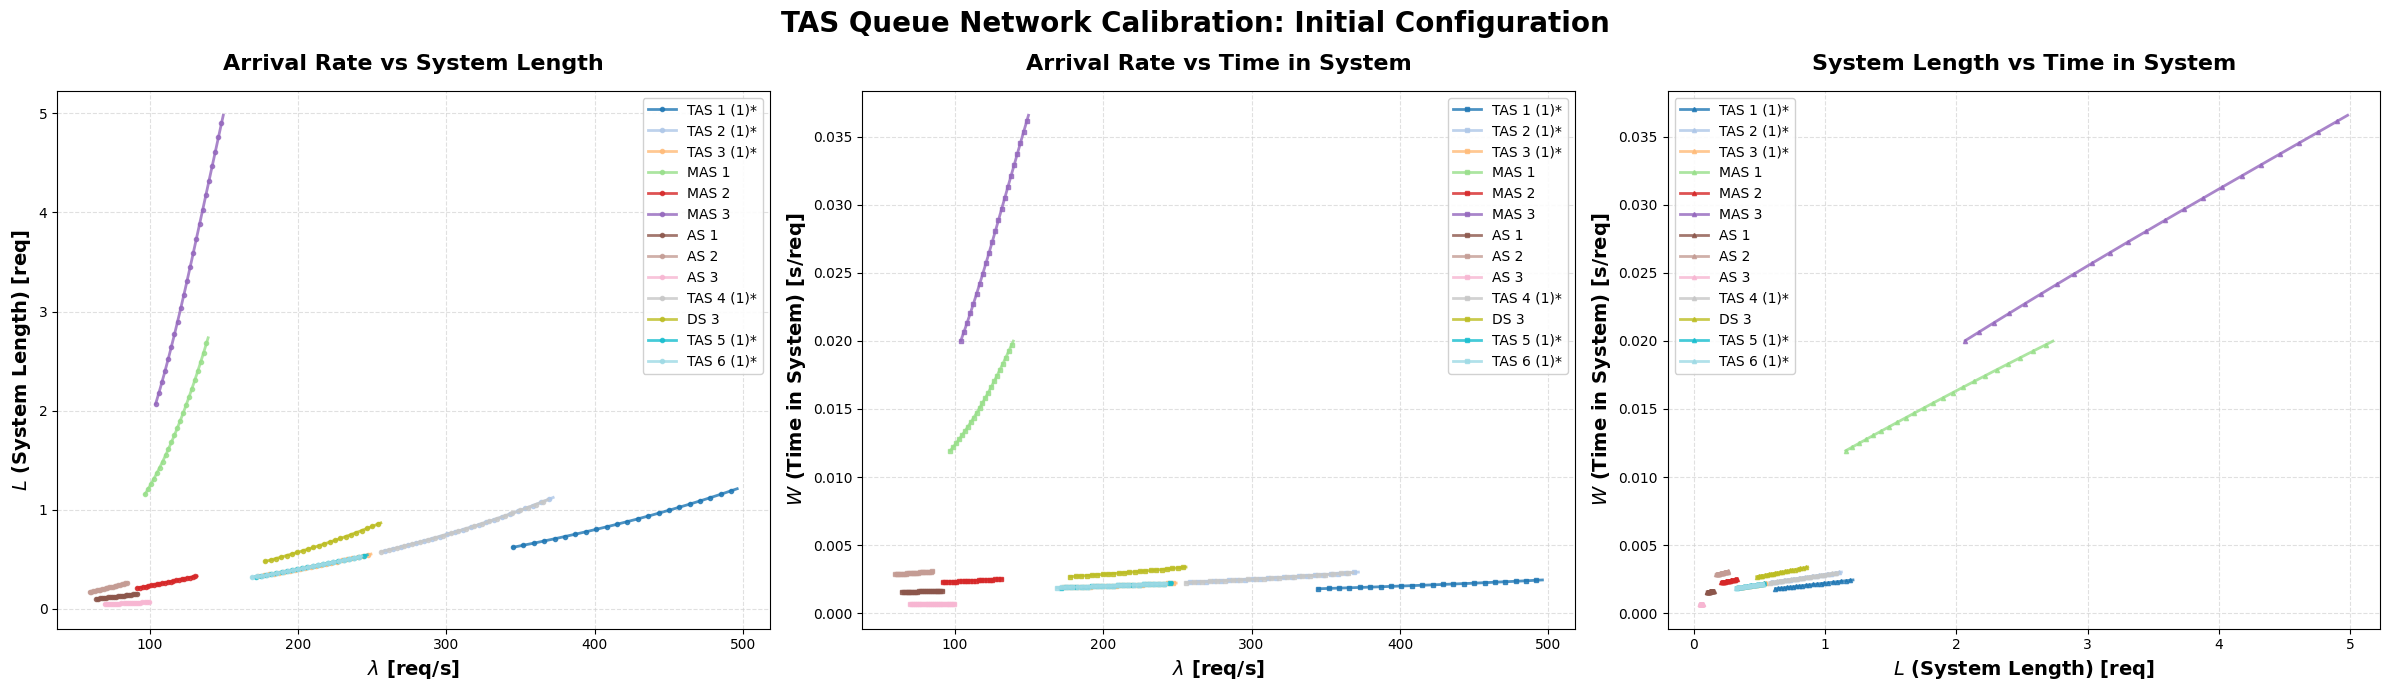

Calibration curves plotted successfully


In [16]:
# After loading calibration data
print("\n--- Plotting Default Calibration Curves ---")

# Define nodes to plot (from your configuration)
nodes = dflt_qn_cfg["node"].values.astype(int).tolist()
node_names = dflt_qn_cfg["name"].values.tolist()

print(f"Nodes: {nodes}")
print(f"Node names: {node_names}")

# Set output path
file_path = os.path.join(PATH,
                         test_folder,
                         calib_folder,
                         results_folder,
                         cs_folder,
                         img_folder)
print(f"File path: {file_path}")

# Plot calibration curves
plot_calibration_curves(calib_df=calib_df,
                        nodes=nodes,
                        node_names=node_names,
                        title="TAS Queue Network Calibration: Initial Configuration",
                        file_path=file_path,
                        fname="dflt_calib_sys_metric_curves.png",)

print("Calibration curves plotted successfully")

##### **Optimized Configuration**

In [17]:
# setting case study data folder
file_path = os.path.join(PATH,
                         test_folder,
                         calib_folder,
                         data_folder,
                         config_folder,
                         cs_folder)
print(f"Configuration file path: {file_path}")

Configuration file path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\tests\calibration\data\config\cs1


In [18]:
# Load configuration with mixed queue models
opti_qn_cfg = load(file_path, "opti_calib_qn_model.csv")
print("Queue Network Configuration:")
# print(opti_qn_cfg)
opti_qn_cfg.head()

Loading configuration from: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\tests\calibration\data\config\cs1\opti_calib_qn_model.csv
Queue Network Configuration:


,node,name,type,mu,c,K,lambda_z,L_z,P_routing
0,1,TAS 1 (1)*,M/M/s/K,900,1,10,345,0,"[0.00,0.75,0.25,0.00,0.00,0.00,0.00,0.00,0.00,..."
1,2,TAS 2 (1)*+,M/M/s/K,700,1,10,0,0,"[0.00,0.00,0.00,0.20,0.40,0.40,0.00,0.00,0.00,..."
2,3,TAS 3 (1)*+,M/M/s/K,700,1,10,0,0,"[0.00,0.00,0.00,0.00,0.00,0.00,0.40,0.40,0.20,..."
3,4,MAS 1,M/M/s/K,180,1,10,0,0,"[0.00,0.00,0.00,0.12,0.00,0.00,0.00,0.00,0.00,..."
4,5,MAS 2,M/M/s/K,530,1,10,0,0,"[0.00,0.00,0.00,0.00,0.07,0.00,0.00,0.00,0.00,..."


In [19]:
print("--- Configuring default analytical model... ---")
opti_analytical_model = config_analytical_model(opti_qn_cfg,
                                                verbose=False)
start_lamba_zp = opti_analytical_model[1][0]
print(f"Starting arrival rate lambda_z at Node 0: {fmt(start_lamba_zp)}")

--- Configuring default analytical model... ---
Starting arrival rate lambda_z at Node 0: 345.0000


In [20]:
# Solve the network analytically
# first node metrics
opti_analyt_nd_metrics = solve_jackson_network(*opti_analytical_model)

In [21]:
print(f"--- Configurating Default Calibration Dataframe ---")
# opti_analyt_nd_metrics.info()
idx_cols = opti_analyt_nd_metrics["node"].values.tolist()
named_cols = opti_analyt_nd_metrics.columns.tolist()
if "node" in named_cols:
    named_cols.remove("node")

print(f"Index columns: {idx_cols}")
print(f"Named columns: {named_cols}")


# create calibration dataframe idx + named colums for each idx
calib_cols = []
for idx in idx_cols:
    for ncol in named_cols:
        tgt_col = f"{ncol}_{{{idx}}}"
        if ncol in ("lambda", "rho", "mu"):
            tgt_col = f"\\{tgt_col}"
        calib_cols.append(tgt_col)
calib_df = pd.DataFrame(columns=calib_cols)
print(f"Default Calibration DataFrame shape: {calib_df.shape}")
calib_df.head()

--- Configurating Default Calibration Dataframe ---
Index columns: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Named columns: ['lambda', 'mu', 'rho', 'L', 'Lq', 'W', 'Wq']
Default Calibration DataFrame shape: (0, 91)


,\lambda_{1},\mu_{1},\rho_{1},L_{1},Lq_{1},W_{1},Wq_{1},\lambda_{2},\mu_{2},\rho_{2},...,Lq_{12},W_{12},Wq_{12},\lambda_{13},\mu_{13},\rho_{13},L_{13},Lq_{13},W_{13},Wq_{13}


In [22]:
print("--- Starting Calibration Loop ---")
RHO_CRIT = 1.0
LAMBDA_CRIT = start_lamba_zp
while any(opti_analyt_nd_metrics["rho"] < RHO_CRIT):
    # print(f"\tλ_zero at Node 0: {fmt(opti_analytical_model[1][0])}")
    
    # error raise iignore and finish the loop
    try:
        opti_analyt_nd_metrics = solve_jackson_network(*opti_analytical_model)
        
        # adding the metrics to the calibration dataframe
        calib_row = {}
        for _, row in opti_analyt_nd_metrics.iterrows():
            node_id = int(row["node"])
            for ncol in named_cols:
                tgt_col = f"{ncol}_{{{node_id}}}"
                if ncol in ("lambda", "rho", "mu"):
                    tgt_col = f"\\{tgt_col}"

                calib_row[tgt_col] = row[ncol]
        calib_df.loc[len(calib_df)] = calib_row
        
    except ValueError as ve:
        print(f"Error encountered: {ve}")
        break
    # print(opti_analyt_nd_metrics.info())
    LAMBDA_CRIT = opti_analytical_model[1][0]
    opti_analytical_model[1][0] += 1  # increase arrival rate lambda_z at Node 0

print(f"Final arrival rate lambda_zero at Node 0: {fmt(LAMBDA_CRIT)}")
print("--- Calibration Loop, Complete ---")

--- Starting Calibration Loop ---
Error encountered: Warning!, unestable system!, calculated rho (ρ): ['0.5556', '0.5357', '0.3607', '0.4735', '0.3043', '0.1853', '0.1621', '0.2566', '0.2672', '0.5357', '1.0000', '0.3607', '0.3536']
Final arrival rate lambda_zero at Node 0: 499.0000
--- Calibration Loop, Complete ---


In [23]:
print("--- Checking Default Calibration Curve ---")
# calib_df.info()
print(f"'Default Calibration DataFrame Shape:': {calib_df.shape}")
calib_df.describe()

--- Checking Default Calibration Curve ---
'Default Calibration DataFrame Shape:': (155, 91)


,\lambda_{1},\mu_{1},\rho_{1},L_{1},Lq_{1},W_{1},Wq_{1},\lambda_{2},\mu_{2},\rho_{2},...,Lq_{12},W_{12},Wq_{12},\lambda_{13},\mu_{13},\rho_{13},L_{13},Lq_{13},W_{13},Wq_{13}
count,155.000000,155.0,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.0,155.000000,...,155.000000,155.000000,155.000000,155.000000,155.0,155.000000,155.000000,155.000000,155.000000,155.000000
mean,422.000000,900.0,0.468889,0.895111,0.426421,0.002102,0.000991,316.500000,700.0,0.452143,...,0.136325,0.002058,0.000630,208.890000,700.0,0.298414,0.428221,0.129809,0.002040,0.000612
std,44.888751,0.0,0.049876,0.176062,0.126565,0.000192,0.000192,33.666564,0.0,0.048095,...,0.034891,0.000096,0.000096,22.219932,0.0,0.031743,0.064750,0.033059,0.000092,0.000092
min,345.000000,900.0,0.383333,0.621333,0.238016,0.001801,0.000690,258.750000,700.0,0.369643,...,0.082473,0.001902,0.000473,170.775000,700.0,0.243964,0.322687,0.078723,0.001890,0.000461
25%,383.500000,900.0,0.426111,0.741574,0.315511,0.001934,0.000823,287.625000,700.0,0.410893,...,0.105816,0.001975,0.000546,189.832500,700.0,0.271189,0.372092,0.100903,0.001960,0.000532
50%,422.000000,900.0,0.468889,0.880195,0.411434,0.002086,0.000975,316.500000,700.0,0.452143,...,0.133232,0.002054,0.000625,208.890000,700.0,0.298414,0.425324,0.126911,0.002036,0.000608
75%,460.500000,900.0,0.511667,1.040857,0.529498,0.002262,0.001151,345.375000,700.0,0.493393,...,0.165221,0.002139,0.000710,227.947500,700.0,0.325639,0.482838,0.157202,0.002118,0.000690
max,499.000000,900.0,0.554444,1.227621,0.673855,0.002463,0.001352,374.250000,700.0,0.534643,...,0.202353,0.002232,0.000803,247.005000,700.0,0.352864,0.545155,0.192297,0.002207,0.000779


In [24]:
print("\n--- Saving Default Calibration (Jackson Network Metrics) ---")
# print(opti_analyt_net_metrics)

# save data
# select result folder
file_path = os.path.join(PATH,
                         test_folder,
                         calib_folder,
                         results_folder,
                         cs_folder,
                         data_folder)
print(f"Data path: {file_path}")
save(file_path, "opti_calib_analytical_net_metrics.csv", calib_df)
calib_df.head()


--- Saving Default Calibration (Jackson Network Metrics) ---
Data path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\tests\calibration\results\cs1\data
Saving data to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\tests\calibration\results\cs1\data\opti_calib_analytical_net_metrics.csv


,\lambda_{1},\mu_{1},\rho_{1},L_{1},Lq_{1},W_{1},Wq_{1},\lambda_{2},\mu_{2},\rho_{2},...,Lq_{12},W_{12},Wq_{12},\lambda_{13},\mu_{13},\rho_{13},L_{13},Lq_{13},W_{13},Wq_{13}
0,345.0,900.0,0.383333,0.621333,0.238016,0.001801,0.000690,258.75,700.0,0.369643,...,0.082473,0.001902,0.000473,170.775,700.0,0.243964,0.322687,0.078723,0.001890,0.000461
1,346.0,900.0,0.384444,0.624250,0.239823,0.001804,0.000693,259.50,700.0,0.370714,...,0.083031,0.001904,0.000475,171.270,700.0,0.244671,0.323925,0.079254,0.001891,0.000463
2,347.0,900.0,0.385556,0.627179,0.241640,0.001808,0.000696,260.25,700.0,0.371786,...,0.083592,0.001906,0.000477,171.765,700.0,0.245379,0.325166,0.079787,0.001893,0.000465
3,348.0,900.0,0.386667,0.630117,0.243468,0.001811,0.000700,261.00,700.0,0.372857,...,0.084156,0.001907,0.000479,172.260,700.0,0.246086,0.326409,0.080323,0.001895,0.000466
4,349.0,900.0,0.387778,0.633066,0.245306,0.001814,0.000703,261.75,700.0,0.373929,...,0.084722,0.001909,0.000481,172.755,700.0,0.246793,0.327654,0.080861,0.001897,0.000468



--- Plotting Default Calibration Curves ---
Nodes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Node names: ['TAS 1 (1)*', 'TAS 2 (1)*+', 'TAS 3 (1)*+', 'MAS 1', 'MAS 2', 'MAS 3->4', 'AS 1', 'AS 2', 'AS 3->4', 'TAS 4 (1)*', 'DS 3->1', 'TAS 5 (1)*', 'TAS 6 (1)*']
File path: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\tests\calibration\results\cs1\img
Saving plot to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\tests\calibration\results\cs1\img\opti_calib_sys_metric_curves.png
Plot saved successfully to: c:\Users\Felipe\OneDrive\Documents\GitHub\DASA-Design\PyDASA-Case-Studies\tests\calibration\results\cs1\img\opti_calib_sys_metric_curves.png


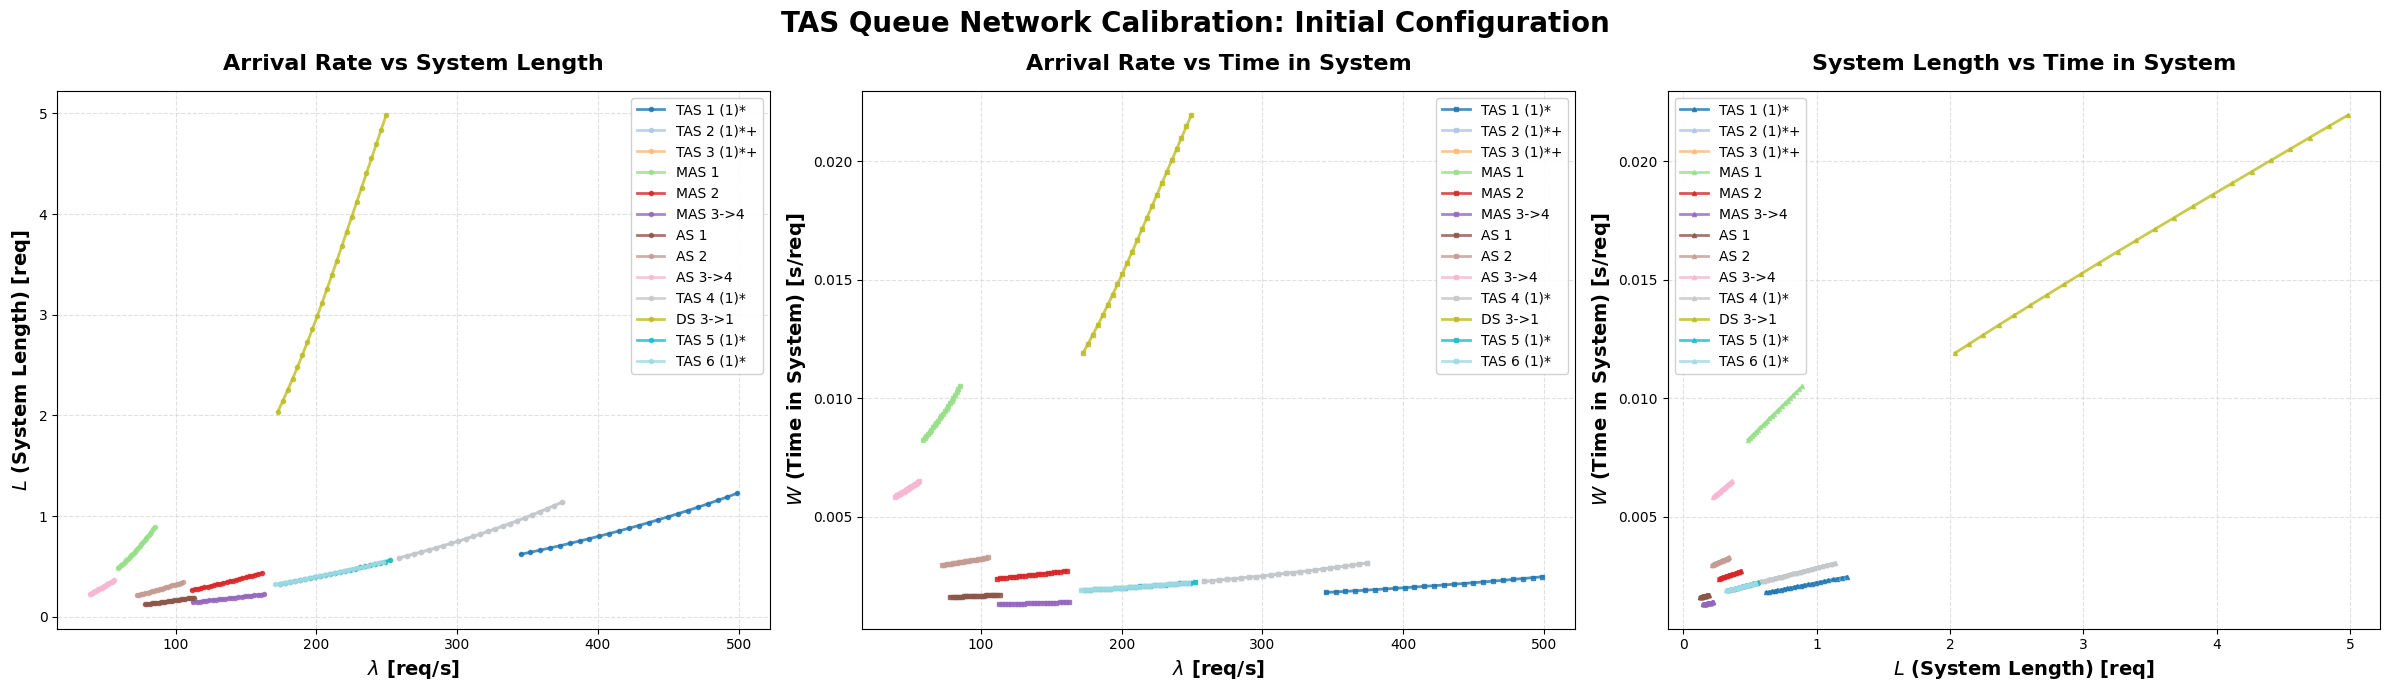

Calibration curves plotted successfully


In [25]:
# After loading calibration data
print("\n--- Plotting Default Calibration Curves ---")

# Define nodes to plot (from your configuration)
nodes = opti_qn_cfg["node"].values.astype(int).tolist()
node_names = opti_qn_cfg["name"].values.tolist()

print(f"Nodes: {nodes}")
print(f"Node names: {node_names}")

# Set output path
file_path = os.path.join(PATH,
                         test_folder,
                         calib_folder,
                         results_folder,
                         cs_folder,
                         img_folder)
print(f"File path: {file_path}")

# Plot calibration curves
plot_calibration_curves(
    calib_df=calib_df,
    nodes=nodes,
    node_names=node_names,
    title="TAS Queue Network Calibration: Initial Configuration",
    file_path=file_path,
    fname="opti_calib_sys_metric_curves.png"
)

print("Calibration curves plotted successfully")

## **Results**

### **Compare Results**

### **Saving Results**

## **Analysis**

### **Graph Analysis**

## **Conclusion**

## **Future Work**

## **References & Sources**
<!-- TODO fix the references, links and details -->
1. [Queueing Theory](https://en.wikipedia.org/wiki/Queueing_theory)
2. [Dimensional Analysis](https://en.wikipedia.org/wiki/Dimensional_analysis)
3. [Simulation in Healthcare](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6466220/)

---

# **HASTA AKI!!!**